<a href="https://colab.research.google.com/github/samsyed004/CV-lab/blob/main/lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification

Investigates how five spatial-domain filters (Average, Gaussian, Median, Sharpening, Sobel) affect classification performance of the three best-performing pretrained models identified in Lab Activity 1 (Task 01), on the **HAM10000** skin-lesion dataset.

**Sections:** Dataset preparation → Model loading → Baseline → Image filtering → Training → Evaluation → Visualization → Comparative analysis


## 1. Install dependencies

In [1]:
!pip install -q opencv-python-headless scikit-learn torchmetrics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.3 MB/s eta 0:00:00


In [2]:
import os, glob
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

os.makedirs("/content/ham10000", exist_ok=True)
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip

print(glob.glob("/content/ham10000/*"))

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:33<00:00, 169MB/s]

['/content/ham10000/ham10000_images_part_2', '/content/ham10000/HAM10000_images_part_2', '/content/ham10000/ham10000_images_part_1', '/content/ham10000/hmnist_28_28_L.csv', '/content/ham10000/HAM10000_metadata.csv', '/content/ham10000/hmnist_8_8_L.csv', '/content/ham10000/HAM10000_images_part_1', '/content/ham10000/hmnist_28_28_RGB.csv', '/content/ham10000/hmnist_8_8_RGB.csv']


In [3]:
CLASS_SUBSET = None   # e.g. ["nv", "mel", "bkl", "bcc"], or None for all 7 classes
SAMPLES_PER_CLASS = 250  # capped for speed; set to None to use every available image per class

## 3. Config — models, filters, hyperparameters

**Speed optimizations applied for faster runs on a free Colab GPU:**
- Only the classification head is trained (the pretrained backbone is frozen) — see `build_model`
- Mixed precision training (`torch.cuda.amp`) — see `train_model`
- Smaller input resolution (`IMG_SIZE = 128`) and fewer epochs (`EPOCHS = 4`)
- Dataset capped at `SAMPLES_PER_CLASS = 250` by default

These make the full 18-run sweep finish much faster, at some cost to peak accuracy. For a final, more rigorous run, unfreeze the backbone (remove `freeze_backbone(...)` calls in `build_model`), raise `EPOCHS`, `IMG_SIZE`, and `SAMPLES_PER_CLASS`, and expect a significantly longer runtime.

In [4]:
import torch

# --- Best three models from Lab Activity 1 (Task 01) ---
# Fill these in with the top-3 models by Accuracy/F1 from your Table 1 results.
# If table1_models.csv from Task 01 is available (e.g. uploaded to this Colab session
# or accessible via Drive), the next cell will auto-pick the top 3; otherwise this
# default list is used.
BEST_MODELS = ["ResNet50", "DenseNet121", "EfficientNet-B0"]

FILTERS = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]

IMG_SIZE    = 128   # smaller input -> much faster per epoch
BATCH_SIZE  = 32
EPOCHS      = 4     # fewer epochs, since only the head is trained (see build_model)
LR          = 1e-4
SEED        = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
import numpy as np, random
np.random.seed(SEED)
random.seed(SEED)

print("Device:", DEVICE)
print("Models to compare:", BEST_MODELS)

Device: cuda
Models to compare: ['ResNet50', 'DenseNet121', 'EfficientNet-B0']


In [5]:
# Optional: auto-select the top 3 models from Task 01's results table.
# Upload table1_models.csv from Task 01 into this Colab session to use this.
import pandas as pd

t1_path = "/content/table1_models.csv"
if os.path.exists(t1_path):
    t1 = pd.read_csv(t1_path).sort_values("Accuracy (%)", ascending=False)
    BEST_MODELS = t1["Model"].head(3).tolist()
    print("Auto-selected best 3 models from Task 01 results:", BEST_MODELS)
else:
    print("table1_models.csv not found — using manually set BEST_MODELS:", BEST_MODELS)

table1_models.csv not found — using manually set BEST_MODELS: ['ResNet50', 'DenseNet121', 'EfficientNet-B0']


## 4. Build the dataset index and a fixed train/val/test split

The **same split** (by `image_id`) is reused for every model × filter combination so all 18 experiments are directly comparable, as required by the task.

In [6]:
import pandas as pd

meta = pd.read_csv("/content/ham10000/HAM10000_metadata.csv")

img_dirs = glob.glob("/content/ham10000/**/*.jpg", recursive=True)
img_lookup = {os.path.splitext(os.path.basename(p))[0]: p for p in img_dirs}
meta["path"] = meta["image_id"].map(img_lookup)
meta = meta.dropna(subset=["path"]).reset_index(drop=True)

if CLASS_SUBSET is not None:
    meta = meta[meta["dx"].isin(CLASS_SUBSET)].reset_index(drop=True)

if SAMPLES_PER_CLASS is not None:
    meta = meta.groupby("dx", group_keys=False).apply(
        lambda g: g.sample(min(len(g), SAMPLES_PER_CLASS), random_state=SEED)
    ).reset_index(drop=True)

class_names = sorted(meta["dx"].unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}
meta["label"] = meta["dx"].map(class_to_idx)
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Total images used:", len(meta))
print(meta["dx"].value_counts())

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Total images used: 1507
dx
akiec    250
bcc      250
bkl      250
mel      250
nv       250
vasc     142
df       115
Name: count, dtype: int64


/tmp/ipykernel_1741/1116308155.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meta = meta.groupby("dx", group_keys=False).apply(


### HAM10000 class distribution

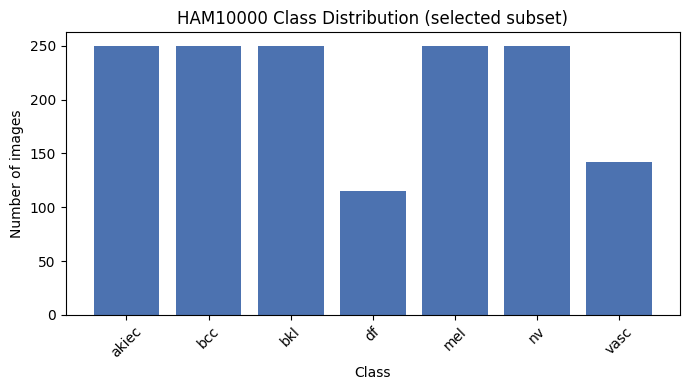

In [7]:
import matplotlib.pyplot as plt

counts = meta["dx"].value_counts().loc[class_names]
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color="#4C72B0")
plt.title("HAM10000 Class Distribution (selected subset)")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(meta, test_size=0.30, stratify=meta["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))

Train: 1054  Val: 226  Test: 227


## 5. Image filtering functions

Each filter operates on an RGB `numpy` array (uint8) and returns a filtered RGB array of the same shape, so it can be dropped straight into the data pipeline before normalization. Sobel produces a single-channel edge map, replicated across 3 channels so it stays compatible with ImageNet-pretrained input stems.

In [9]:
import cv2
import numpy as np

def apply_filter(img_np, filter_name):
    """img_np: HxWx3 uint8 RGB array. Returns HxWx3 uint8 RGB array."""
    if filter_name == "No Filter":
        return img_np
    if filter_name == "Average":
        return cv2.blur(img_np, (5, 5))
    if filter_name == "Gaussian":
        return cv2.GaussianBlur(img_np, (5, 5), sigmaX=1.0)
    if filter_name == "Median":
        return cv2.medianBlur(img_np, 5)
    if filter_name == "Sharpening":
        kernel = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]], dtype=np.float32)
        sharpened = cv2.filter2D(img_np, -1, kernel)
        return np.clip(sharpened, 0, 255).astype(np.uint8)
    if filter_name == "Sobel":
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(sx ** 2 + sy ** 2)
        mag = np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
        return np.stack([mag, mag, mag], axis=-1)
    raise ValueError(filter_name)

### Original vs. filtered examples

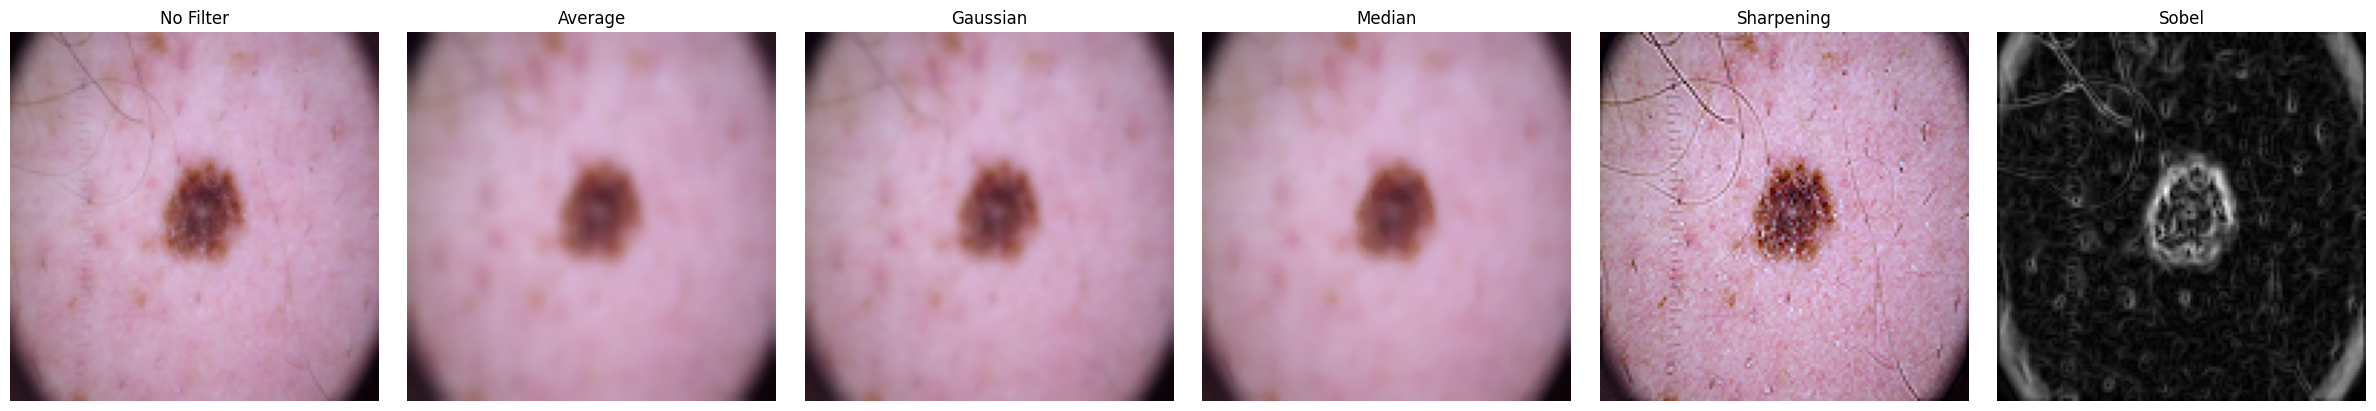

In [10]:
from PIL import Image

sample_path = train_df.iloc[0]["path"]
sample_img = np.array(Image.open(sample_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))

fig, axes = plt.subplots(1, len(FILTERS), figsize=(4 * len(FILTERS), 4))
for ax, f in zip(axes, FILTERS):
    filtered = apply_filter(sample_img, f)
    ax.imshow(filtered)
    ax.set_title(f)
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/filter_examples.png", dpi=150)
plt.show()

## 6. PyTorch Dataset applying a chosen filter

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class HAM10000Dataset(Dataset):
    def __init__(self, df, filter_name, augment=False):
        self.df = df.reset_index(drop=True)
        self.filter_name = filter_name
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_np = np.array(img)
        img_np = apply_filter(img_np, self.filter_name)

        if self.augment:
            if random.random() < 0.5:
                img_np = np.fliplr(img_np).copy()

        tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        tensor = (tensor - mean) / std
        return tensor, row["label"]

def make_loaders(filter_name):
    train_ds = HAM10000Dataset(train_df, filter_name, augment=True)
    val_ds   = HAM10000Dataset(val_df,   filter_name, augment=False)
    test_ds  = HAM10000Dataset(test_df,  filter_name, augment=False)
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2),
        DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
        DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    )

## 7. Model loading

In [12]:
import torch.nn as nn
import torchvision.models as tvm

def freeze_backbone(m):
    """Freezes every parameter, so only layers replaced afterwards (the new
    classification head) will have requires_grad=True and get trained.
    This is what makes each run fast: the pretrained convolutional features
    are reused as-is and only the head is fit to HAM10000."""
    for p in m.parameters():
        p.requires_grad = False
    return m

def build_model(name, num_classes=None):
    num_classes = num_classes or NUM_CLASSES
    if name == "AlexNet":
        m = freeze_backbone(tvm.alexnet(weights=tvm.AlexNet_Weights.DEFAULT))
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "VGG16":
        m = freeze_backbone(tvm.vgg16(weights=tvm.VGG16_Weights.DEFAULT))
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "VGG19":
        m = freeze_backbone(tvm.vgg19(weights=tvm.VGG19_Weights.DEFAULT))
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "ResNet18":
        m = freeze_backbone(tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT))
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "ResNet50":
        m = freeze_backbone(tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT))
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "ResNet101":
        m = freeze_backbone(tvm.resnet101(weights=tvm.ResNet101_Weights.DEFAULT))
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "DenseNet121":
        m = freeze_backbone(tvm.densenet121(weights=tvm.DenseNet121_Weights.DEFAULT))
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    elif name == "EfficientNet-B0":
        m = freeze_backbone(tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.DEFAULT))
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unrecognized model name: {name}")
    # newly-created head layers default to requires_grad=True, so only they train
    return m

## 8. Training and evaluation functions

Same training settings (optimizer, LR, epochs, batch size) are used for every model × filter run to keep the comparison fair, as the task requires.

In [13]:
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, balanced_accuracy_score,
                              classification_report)

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    # only the unfrozen head parameters need gradients/updates -> much faster per step
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                    out = model(x)
                    loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += y.size(0)
        val_loss = v_loss / v_total
        val_acc = v_correct / v_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"  epoch {epoch+1}/{epochs} - train_acc {history['train_acc'][-1]:.3f} "
              f"- val_acc {val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, history

def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            probs = F.softmax(model(x), dim=1).cpu().numpy()
            all_preds.extend(probs.argmax(1))
            all_labels.extend(y.numpy())
            all_probs.extend(probs)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1  # macro-F1 is the same macro-averaged F1 reported above
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names,
                                    output_dict=True, zero_division=0)

    metrics = {
        "Accuracy": round(acc * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2),
        "F1-score": round(f1 * 100, 2),
        "Macro-F1": round(macro_f1 * 100, 2),
        "AUC": round(auc * 100, 2),
        "Balanced Accuracy": round(bal_acc * 100, 2),
    }
    return metrics, cm, report, y_true, y_prob

## 9. Baseline experiment + full model × filter comparison

Runs all 3 models × 6 conditions ('No Filter' baseline + 5 filters) = **18 experiments**, all using the identical split, preprocessing pipeline, and training settings defined above.

In [14]:
results = []
histories = {}
confusion_matrices = {}
class_reports = {}
roc_data = {}

for model_name in BEST_MODELS:
    for filter_name in FILTERS:
        run_id = f"{model_name} | {filter_name}"
        print(f"\n=== Training {run_id} ===")

        train_loader, val_loader, test_loader = make_loaders(filter_name)
        model = build_model(model_name)
        model, history = train_model(model, train_loader, val_loader)
        metrics, cm, report, y_true, y_prob = evaluate_model(model, test_loader)

        metrics["Model"] = model_name
        metrics["Filter"] = filter_name
        results.append(metrics)

        histories[run_id] = history
        confusion_matrices[run_id] = cm
        class_reports[run_id] = report
        roc_data[run_id] = (y_true, y_prob)

        model.cpu()
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)[
    ["Model", "Filter", "Accuracy", "Precision", "Recall", "F1-score", "Macro-F1", "AUC"]
]
print("\n=== Full comparison table ===")
print(results_df.to_string(index=False))
results_df.to_csv("/content/filter_comparison_table.csv", index=False)


=== Training ResNet50 | No Filter ===
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 122MB/s]
/tmp/ipykernel_1741/1109680901.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
/tmp/ipykernel_1741/1109680901.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_1741/1109680901.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


  epoch 1/4 - train_acc 0.228 - val_acc 0.319
  epoch 2/4 - train_acc 0.310 - val_acc 0.327
  epoch 3/4 - train_acc 0.400 - val_acc 0.381
  epoch 4/4 - train_acc 0.436 - val_acc 0.420

=== Training ResNet50 | Average ===


/tmp/ipykernel_1741/1109680901.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
/tmp/ipykernel_1741/1109680901.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_1741/1109680901.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


  epoch 1/4 - train_acc 0.183 - val_acc 0.230
  epoch 2/4 - train_acc 0.257 - val_acc 0.261
  epoch 3/4 - train_acc 0.332 - val_acc 0.292
  epoch 4/4 - train_acc 0.379 - val_acc 0.358

=== Training ResNet50 | Gaussian ===


...

  epoch 1/4 - train_acc 0.167 - val_acc 0.204
  epoch 2/4 - train_acc 0.244 - val_acc 0.279
  epoch 3/4 - train_acc 0.282 - val_acc 0.319
  epoch 4/4 - train_acc 0.342 - val_acc 0.345

=== Training EfficientNet-B0 | Sharpening ===


/tmp/ipykernel_1741/1109680901.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
/tmp/ipykernel_1741/1109680901.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_1741/1109680901.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


  epoch 1/4 - train_acc 0.172 - val_acc 0.252
  epoch 2/4 - train_acc 0.228 - val_acc 0.257
  epoch 3/4 - train_acc 0.277 - val_acc 0.341
  epoch 4/4 - train_acc 0.327 - val_acc 0.367

=== Training EfficientNet-B0 | Sobel ===


/tmp/ipykernel_1741/1109680901.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
/tmp/ipykernel_1741/1109680901.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_1741/1109680901.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


  epoch 1/4 - train_acc 0.180 - val_acc 0.195
  epoch 2/4 - train_acc 0.219 - val_acc 0.230
  epoch 3/4 - train_acc 0.257 - val_acc 0.279
  epoch 4/4 - train_acc 0.318 - val_acc 0.314

=== Full comparison table ===
          Model     Filter  Accuracy  Precision  Recall  F1-score  Macro-F1   AUC
       ResNet50  No Filter     43.17      44.14   39.09     38.61     38.61 75.54
       ResNet50    Average     36.12      34.75   32.22     31.31     31.31 73.12
       ResNet50   Gaussian     40.97      39.53   36.38     34.53     34.53 73.96
       ResNet50     Median     35.68      34.01   31.80     30.50     30.50 75.52
       ResNet50 Sharpening     40.09      41.97   35.94     35.04     35.04 74.87
       ResNet50      Sobel     29.96      27.78   27.25     26.42     26.42 68.48
    DenseNet121  No Filter     30.84      35.42   27.92     27.57     27.57 69.90
    DenseNet121    Average     34.36      39.65   31.15     31.39     31.39 69.88
    DenseNet121   Gaussian     30.84      27.61

## 10. Visualization

### Training/validation accuracy and loss curves (per experiment)

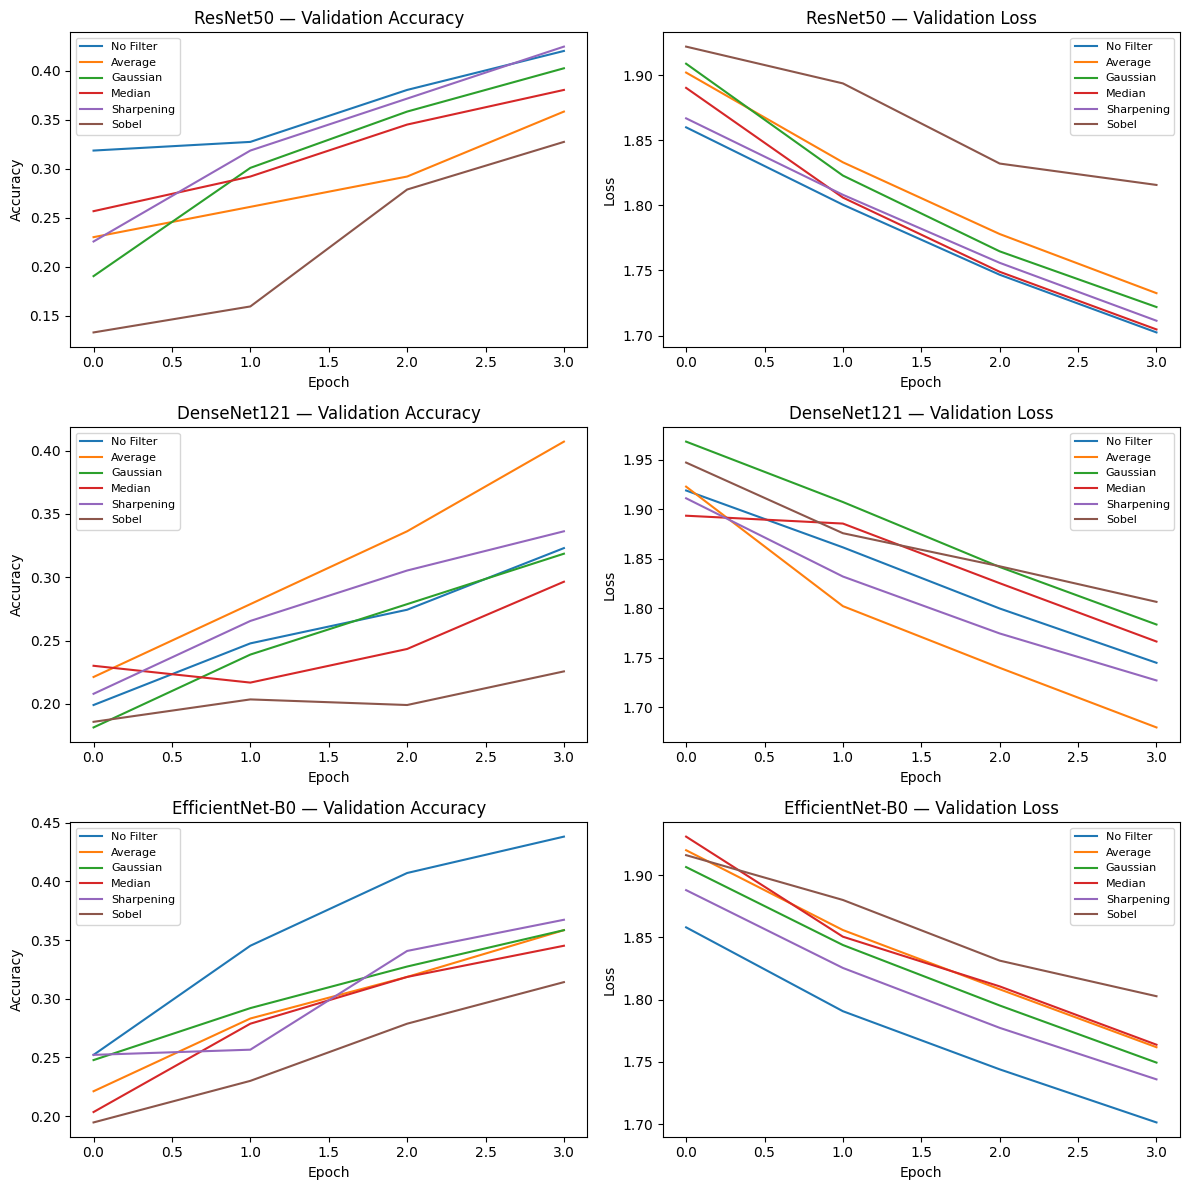

In [15]:
fig, axes = plt.subplots(len(BEST_MODELS), 2, figsize=(12, 4 * len(BEST_MODELS)))
for i, model_name in enumerate(BEST_MODELS):
    ax_acc, ax_loss = axes[i]
    for filter_name in FILTERS:
        h = histories[f"{model_name} | {filter_name}"]
        ax_acc.plot(h["val_acc"], label=filter_name)
        ax_loss.plot(h["val_loss"], label=filter_name)
    ax_acc.set_title(f"{model_name} — Validation Accuracy")
    ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy"); ax_acc.legend(fontsize=8)
    ax_loss.set_title(f"{model_name} — Validation Loss")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss"); ax_loss.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150)
plt.show()

### Confusion matrices

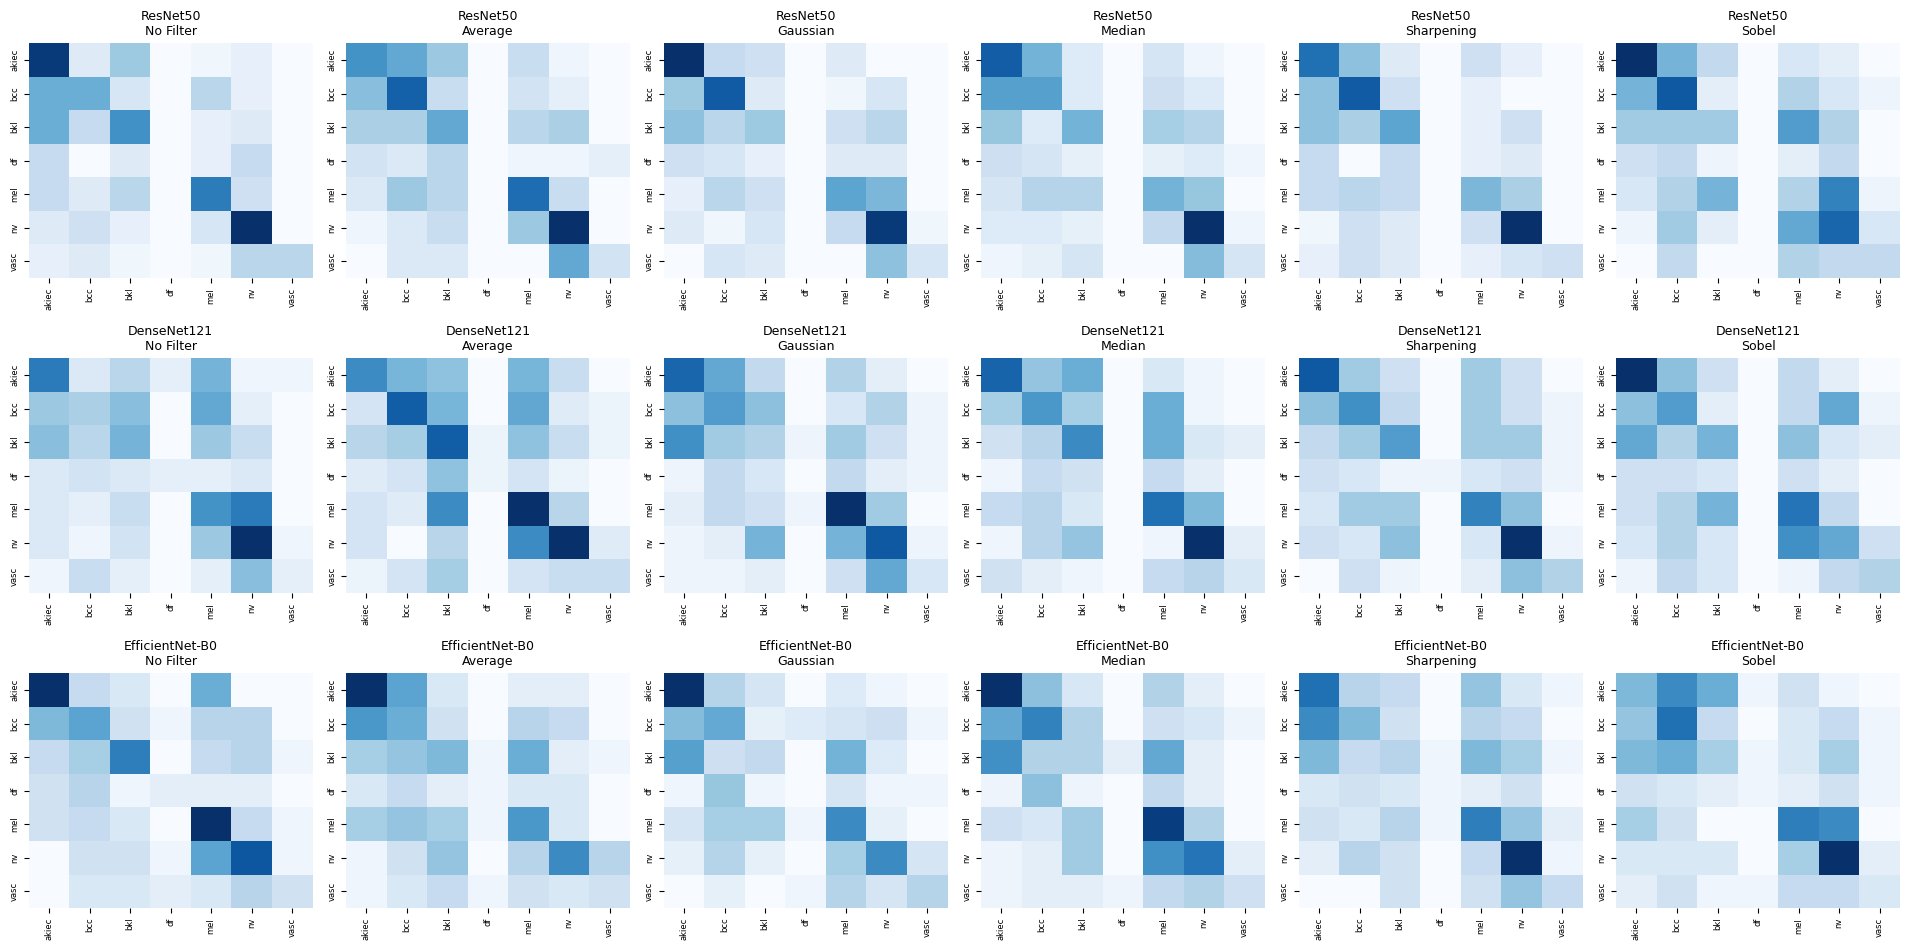

In [16]:
import seaborn as sns

n = len(BEST_MODELS) * len(FILTERS)
cols = len(FILTERS)
fig, axes = plt.subplots(len(BEST_MODELS), cols, figsize=(3.2 * cols, 3.2 * len(BEST_MODELS)))
for i, model_name in enumerate(BEST_MODELS):
    for j, filter_name in enumerate(FILTERS):
        ax = axes[i][j] if len(BEST_MODELS) > 1 else axes[j]
        cm = confusion_matrices[f"{model_name} | {filter_name}"]
        sns.heatmap(cm, annot=False, cmap="Blues", ax=ax, cbar=False,
                    xticklabels=class_names, yticklabels=class_names)
        ax.set_title(f"{model_name}\n{filter_name}", fontsize=9)
        ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig("/content/confusion_matrices.png", dpi=150)
plt.show()

### Per-class precision, recall, F1 (baseline vs. best filter per model)

In [17]:
per_class_rows = []
for model_name in BEST_MODELS:
    for filter_name in FILTERS:
        report = class_reports[f"{model_name} | {filter_name}"]
        for cls in class_names:
            per_class_rows.append({
                "Model": model_name, "Filter": filter_name, "Class": cls,
                "Precision": round(report[cls]["precision"] * 100, 2),
                "Recall": round(report[cls]["recall"] * 100, 2),
                "F1-score": round(report[cls]["f1-score"] * 100, 2),
            })
per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv("/content/per_class_metrics.csv", index=False)
per_class_df.head(20)

,Model,Filter,Class,Precision,Recall,F1-score
0,ResNet50,No Filter,akiec,35.94,60.53,45.10
1,ResNet50,No Filter,bcc,37.50,32.43,34.78
2,ResNet50,No Filter,bkl,36.59,39.47,37.97
3,ResNet50,No Filter,df,0.00,0.00,0.00
4,ResNet50,No Filter,mel,50.00,44.74,47.22
5,ResNet50,No Filter,nv,48.98,63.16,55.17
6,ResNet50,No Filter,vasc,100.00,33.33,50.00
7,ResNet50,Average,akiec,35.14,34.21,34.67
8,ResNet50,Average,bcc,32.69,45.95,38.20
9,ResNet50,Average,bkl,25.00,28.95,26.83


### ROC curves (macro one-vs-rest) per model, No Filter vs. filtered

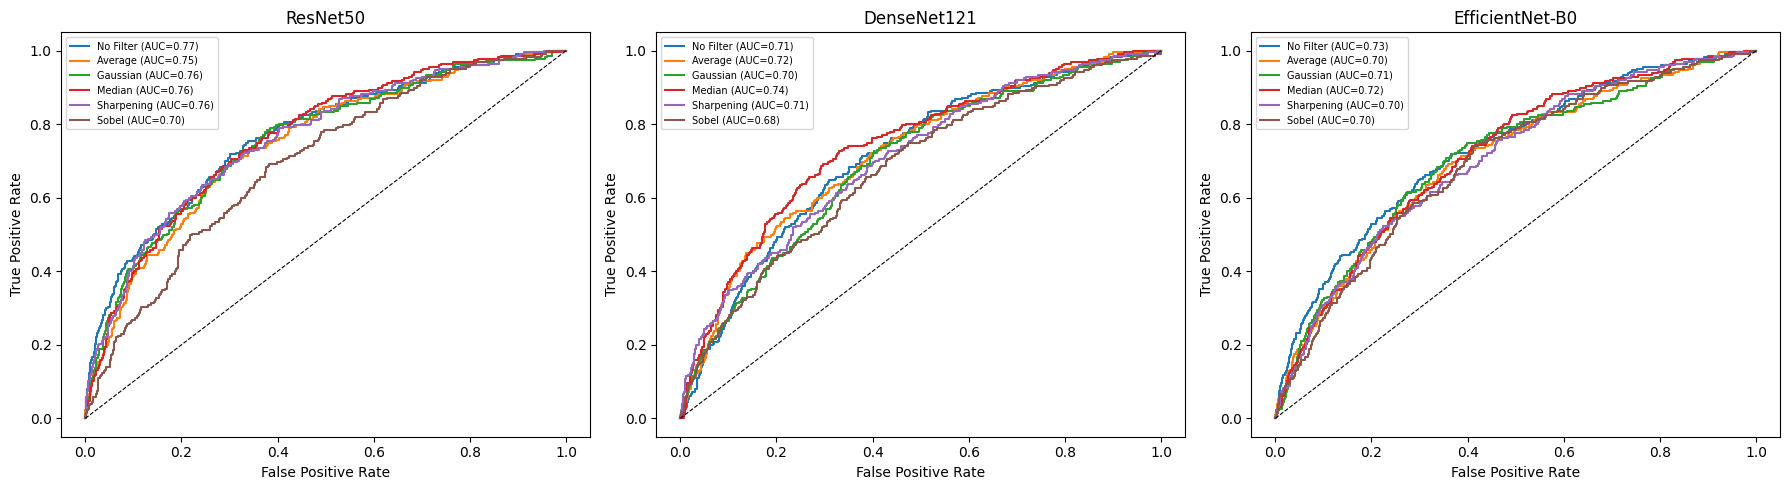

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as auc_fn

fig, axes = plt.subplots(1, len(BEST_MODELS), figsize=(6 * len(BEST_MODELS), 5))
if len(BEST_MODELS) == 1:
    axes = [axes]

for ax, model_name in zip(axes, BEST_MODELS):
    for filter_name in FILTERS:
        y_true, y_prob = roc_data[f"{model_name} | {filter_name}"]
        y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        fpr, tpr, _ = roc_curve(y_bin.ravel(), y_prob.ravel())
        roc_auc = auc_fn(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{filter_name} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_title(model_name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("/content/roc_curves.png", dpi=150)
plt.show()

## 11. Comparative analysis

Computes, per model, the change in each metric relative to the 'No Filter' baseline — this is the quantitative basis for answering the write-up questions below.

In [19]:
baseline = results_df[results_df["Filter"] == "No Filter"].set_index("Model")
delta_rows = []
for _, row in results_df.iterrows():
    if row["Filter"] == "No Filter":
        continue
    base = baseline.loc[row["Model"]]
    delta_rows.append({
        "Model": row["Model"],
        "Filter": row["Filter"],
        "ΔAccuracy": round(row["Accuracy"] - base["Accuracy"], 2),
        "ΔMacro-F1": round(row["Macro-F1"] - base["Macro-F1"], 2),
        "ΔAUC": round(row["AUC"] - base["AUC"], 2),
    })
delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv("/content/filter_effect_deltas.csv", index=False)
print("Change relative to each model's No-Filter baseline:")
delta_df.sort_values("ΔMacro-F1")

Change relative to each model's No-Filter baseline:


,Model,Filter,ΔAccuracy,ΔMacro-F1,ΔAUC
4,ResNet50,Sobel,-13.21,-12.19,-7.06
14,EfficientNet-B0,Sobel,-8.37,-8.76,-4.51
2,ResNet50,Median,-7.49,-8.11,-0.02
10,EfficientNet-B0,Average,-8.37,-7.87,-3.39
13,EfficientNet-B0,Sharpening,-7.93,-7.48,-2.98
0,ResNet50,Average,-7.05,-7.30,-2.42
12,EfficientNet-B0,Median,-6.17,-7.27,-0.92
11,EfficientNet-B0,Gaussian,-4.41,-4.71,-3.12
1,ResNet50,Gaussian,-2.20,-4.08,-1.58
3,ResNet50,Sharpening,-3.08,-3.57,-0.67


In [20]:
# Automated pointers to help answer the write-up questions — inspect these before writing your answers.
largest_change = delta_df.loc[delta_df["ΔMacro-F1"].abs().idxmax()]
print("Filter with the single largest Macro-F1 change from baseline:")
print(largest_change)

print("\nAverage ΔMacro-F1 per filter, across all 3 models (consistency check):")
print(delta_df.groupby("Filter")["ΔMacro-F1"].agg(["mean", "std"]))

Filter with the single largest Macro-F1 change from baseline:
Model        ResNet50
Filter          Sobel
ΔAccuracy      -13.21
ΔMacro-F1      -12.19
ΔAUC            -7.06
Name: 4, dtype: object

Average ΔMacro-F1 per filter, across all 3 models (consistency check):
                mean       std
Filter                        
Average    -3.783333  6.590845
Gaussian   -3.383333  1.780346
Median     -4.400000  5.713904
Sharpening -2.206667  6.070917
Sobel      -7.140000  6.025604


## 12. Export all results

In [21]:
with pd.ExcelWriter("/content/lab02_results.xlsx") as writer:
    results_df.to_excel(writer, sheet_name="Comparison_Table", index=False)
    delta_df.to_excel(writer, sheet_name="Filter_Effect_Deltas", index=False)
    per_class_df.to_excel(writer, sheet_name="Per_Class_Metrics", index=False)

from google.colab import files as colab_files
colab_files.download("/content/lab02_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Questions to Answer

Use `results_df`, `delta_df`, and the plots above as evidence for each answer.

1. **Which three pretrained models performed best in Lab Activity 1?**
   → `BEST_MODELS` above (auto-loaded from Task 01's `table1_models.csv`, or set manually).

2. **How does filtering affect each of the three models?**
   → See each model's row group in `results_df` / its panel in the training-curve and confusion-matrix figures.

3. **Which filter produces the greatest change compared with the unfiltered baseline?**
   → `largest_change` printed in Section 11.

4. **Does the effect of a filter remain consistent across all three models?**
   → Check the `std` column from `delta_df.groupby("Filter")` in Section 11 — a small std means consistent effect, a large std means model-dependent effect.

5. **Does filtering improve or decrease macro-F1 and balanced accuracy?**
   → `delta_df["ΔMacro-F1"]` sign, and compare `Balanced Accuracy` values captured in `metrics` (also in `results_df` if you add that column back in).

6. **Which lesion classes are most affected by filtering?**
   → `per_class_df`, comparing each class's F1-score across filters for a given model.

7. **Why might smoothing remove useful lesion texture or morphological information?**
   → Discuss with reference to how Average/Gaussian/Median filters attenuate high-frequency detail (border irregularity, texture) that dermatological classification relies on.

8. **Why might sharpening or edge detection help or hurt classification?**
   → Discuss how emphasizing edges can highlight lesion borders but also amplify noise/hair artifacts, and how Sobel discards color/texture information entirely.

9. **What is the difference between convolution and correlation?**
   → Convolution flips the kernel (180°) before sliding it over the image; correlation does not. Most deep-learning "convolution" layers (and OpenCV's `filter2D`) actually implement cross-correlation in practice, since the kernel is learned rather than fixed, and flipping a learned kernel makes no mathematical difference to what's learned.

10. **Relationship between classical image processing and deep-learning-based feature extraction?**
   → Reflect on your results: pretrained CNNs already learn their own low-level filters (edge/texture detectors) in early layers, so hand-crafted filters can be redundant, harmful (destroying information the CNN would otherwise learn to use), or occasionally helpful (denoising) depending on the filter and dataset.